A shape: (100, 2) y shape: (100,)


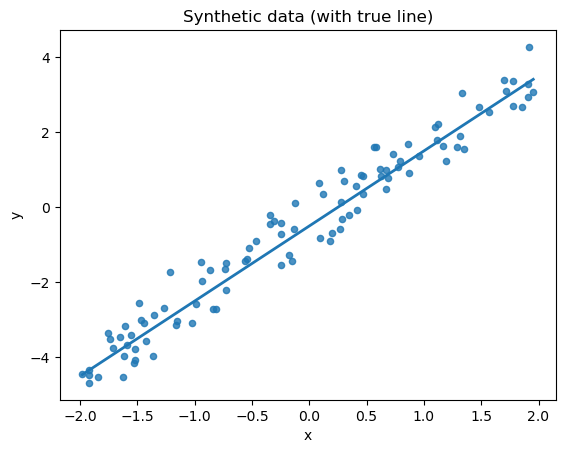

In [1]:
# ====== Step 1: imports & data generation ======
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

n = 100
x = np.random.uniform(-2.0, 2.0, size=n)              # 1D feature
true_w1 = 2.0
true_b  = -0.5
noise_std = 0.5

y = true_w1 * x + true_b + np.random.normal(0, noise_std, size=n)

# Design matrix A: shape (100, 2) = [x, 1]
A = np.column_stack([x, np.ones_like(x)])

print("A shape:", A.shape, "y shape:", y.shape)

# quick scatter
plt.figure()
plt.scatter(x, y, s=20, alpha=0.8)
xx = np.linspace(x.min(), x.max(), 200)
plt.plot(xx, true_w1*xx + true_b, linewidth=2)
plt.title("Synthetic data (with true line)")
plt.xlabel("x"); plt.ylabel("y")
plt.show()

In [2]:
# ====== Step 2: objective, gradient, and Lipschitz-based step size ======
def f(w):
    ##TODO: return the loss function 0.5||Aw-y||^2   
    r=A@w-y
    return 0.5*np.dot(r,r)
def grad(w):
    ##TODO: return the gradient at point w
    return A.T@(A@w-y)

# TODO: find Lipschitz constant of grad: L = ||A^T A||_2 (largest eigenvalue)

L = np.linalg.eigvalsh(A.T@A).max()
# TODO: set stepsize (eta) as 1/L 
eta = 1/L   # safe step size for convex quadratic

print(f"L = {L:.6f}, suggested eta = 1/L = {eta:.6f}")

L = 137.344054, suggested eta = 1/L = 0.007281


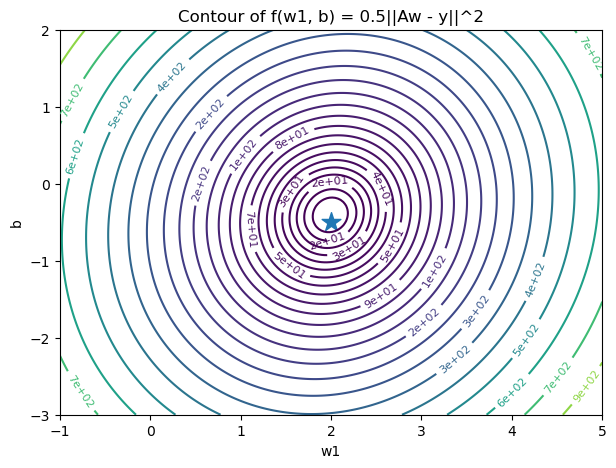

In [3]:
# ====== Cell 3: contour plot of f(w1, b) over a grid ======
# We'll plot in coordinates (w1, b) where w = [w1, b]
w1_min, w1_max = -1.0, 5.0
b_min,  b_max  = -3.0, 2.0

grid_n = 200
w1_grid = np.linspace(w1_min, w1_max, grid_n)
b_grid  = np.linspace(b_min, b_max, grid_n)

W1, B = np.meshgrid(w1_grid, b_grid)
Z = np.empty_like(W1)

# Evaluate objective on grid
for i in range(grid_n):
    # vectorize over w1 dimension for speed
    w_batch = np.stack([W1[i, :], B[i, :]], axis=1)  # shape (grid_n, 2)
    # compute f for each row
    r = (A @ w_batch.T) - y[:, None]                 # shape (n, grid_n)
    Z[i, :] = 0.5 * np.sum(r**2, axis=0)

plt.figure(figsize=(7, 5))
levels = np.geomspace(Z.min() + 1e-6, Z.max(), 25)  # geometric levels look nicer
cs = plt.contour(W1, B, Z, levels=levels)
plt.clabel(cs, inline=1, fontsize=8, fmt="%.0e")
plt.title("Contour of f(w1, b) = 0.5||Aw - y||^2")
plt.xlabel("w1"); plt.ylabel("b")
plt.scatter([true_w1], [true_b], marker="*", s=200)  # true parameters (approx best)
#plt.gca().set_aspect('equal', adjustable='box')
plt.show()
#plt.axis('equal')

Initial f: 563.7534704254601 Final f: 12.405483109058103
Final w: [ 1.99211688 -0.40469071]


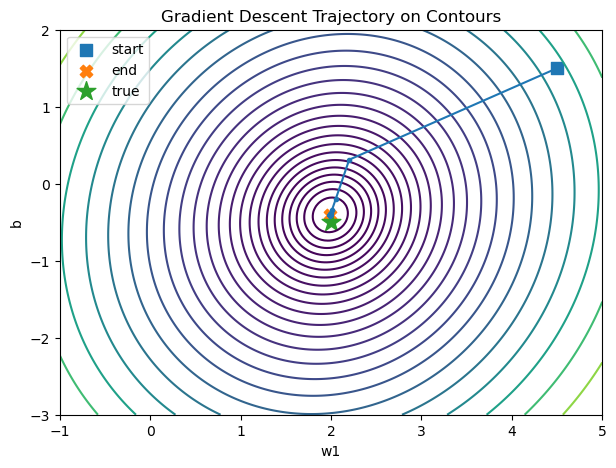

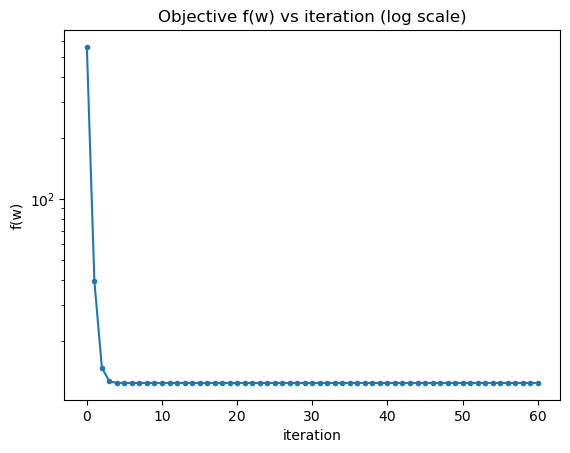

In [4]:
# ====== Cell 4: gradient descent + plot trajectory on contour ======
def gradient_descent(w0, eta, steps=50):
    w = w0.astype(float).copy()
    traj = [w.copy()]
    vals = [f(w)]
    for _ in range(steps):
        ##TODO: Gradient descent 
        w = w - eta*grad(w)
        traj.append(w.copy())
        vals.append(f(w))
    return np.array(traj), np.array(vals)

# initial point
w0 = np.array([4.5, 1.5])  # start far away
steps = 60
##TODO: Please carefully set eta = 1*eta, eta=2*eta, eta=0.5*eta, what do you find?
traj, vals = gradient_descent(w0, eta=1*eta, steps=steps)

print("Initial f:", vals[0], "Final f:", vals[-1])
print("Final w:", traj[-1])

# Plot contour + GD path
plt.figure(figsize=(7, 5))
levels = np.geomspace(Z.min() + 1e-6, Z.max(), 25)
plt.contour(W1, B, Z, levels=levels)
plt.plot(traj[:, 0], traj[:, 1], marker="o", markersize=3, linewidth=1.5)
plt.scatter([traj[0, 0]], [traj[0, 1]], s=80, marker="s", label="start")
plt.scatter([traj[-1, 0]], [traj[-1, 1]], s=80, marker="X", label="end")
plt.scatter([true_w1], [true_b], marker="*", s=200, label="true")
plt.title("Gradient Descent Trajectory on Contours")
plt.xlabel("w1"); plt.ylabel("b")
plt.legend()
plt.show()

# Plot objective value vs iteration
plt.figure()
plt.plot(vals, marker="o", markersize=3)
plt.yscale("log")
plt.title("Objective f(w) vs iteration (log scale)")
plt.xlabel("iteration"); plt.ylabel("f(w)")
#plt.gca().set_aspect('equal', adjustable='box')
plt.show()
#plt.axis('equal')

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

np.random.seed(0)

n = 100

# 2D features
x1 = np.random.uniform(-2, 2, n)
x2 = np.random.uniform(-2, 2, n)

true_w = np.array([2.0, -1.5])
true_b = 0.7

noise = np.random.normal(0, 0.5, n)

y = true_w[0]*x1 + true_w[1]*x2 + true_b + noise

# Design matrix (100 x 3)
A = np.column_stack([x1, x2, np.ones(n)])

print("A shape:", A.shape)

A shape: (100, 3)


In [6]:


#TODO: to compute Lipschitz constant
L = np.linalg.eigvalsh(A.T@A).max()
eta = 1.0 / L

print("Step size:", eta)

Step size: 0.0068930769260079705


In [7]:
def gradient_descent(w0, eta, steps=60):
    w = w0.astype(float).copy()
    traj = [w.copy()]
    vals = [f(w)]
    for _ in range(steps):
        ##TODO: gradient descent
        w = w - eta*grad(w)
        traj.append(w.copy())
        vals.append(f(w))
    return np.array(traj), np.array(vals)

w0 = np.array([3.0, 3.0, 3.0])
steps = 60
traj, vals = gradient_descent(w0, eta, steps=steps)

# closed-form optimum by np.linalg.lstsq
w_star = np.linalg.lstsq(A, y, rcond=None)[0]
# Another option is to use LinearRegression in sklearn.linear_model, which admit same outcomes

## we want to compare the output by gradient descent with optimum by np.linalg.lstsq
## TODO: check our own output
print("GD final w:", traj[-1])
print("LS  w*     :", w_star)
# Apparently, the outcomes validate GD is great, it works very well.

GD final w: [ 1.93104431 -1.53235585  0.65102957]
LS  w*     : [ 1.93104431 -1.53235585  0.65102957]


In [8]:
## Apparently, some of the above coefficients can be negative. However, in real life
## some components are only additive, which requires the coefficient to be nonnegative
## Now we use sklearn to find the best solution
## As A has one column with all ones, we should set fit_intercept=false to avoid
## repeated calculation for intercept
## in https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html
## they provide the option positive=True for nonnegative least squares
from sklearn.linear_model import LinearRegression
reg = LinearRegression(fit_intercept=False,positive=True).fit(A, y)

In [9]:
reg.coef_

array([2.02827066, 0.        , 0.48948522])

In [10]:
## Apparently the above solution are nonnegative, but it remains mystyrious how they come to
## to above solution, we turn to make use our friend Gradient descent again except this time we 
## choose its sibling: projected gradient descent, which says after each vanilla gradient descent
## step, we make sure everything is nonnegative, a natural way is max{w,0} to pull w back 
## to be non-negative

In [11]:
def p_gradient_descent(w0, eta, steps=60):
    w = w0.astype(float).copy()
    traj = [w.copy()]
    vals = [f(w)]
    for _ in range(steps):
        ##TODO:
        w=np.maximum(w-eta*grad(w),0)
        traj.append(w.copy())
        vals.append(f(w))
    return np.array(traj), np.array(vals)

w0 = np.array([3.0, 3.0, 3.0])
steps = 60
traj, vals = p_gradient_descent(w0, eta, steps=steps)
print("Nonnegative GD final w:", traj[-1])

Nonnegative GD final w: [2.02827066 0.         0.48948522]


In [12]:
## Apparently, projected gd yields same result as sklearn
## Congratulations, you have finished this part.
## However, you may be wondering why this simple and naive operation max{w,0} works
## is it due to good luck or it works for arbitary case, we will
## discuss this in Advanced Machine Learning